# 🤖 Bipedal Balancing Robot — Calibration & PID Tuner

**Workflow Overview:**
1. **Connect** to the STM32 via serial (COM port)
2. **Calibrate** the IMU with motors OFF — find the true upright zero
3. **Observe** the live pitch stream to verify sensor health
4. **Tune PID** parameters interactively (Kp → Kd → Ki) with motors still OFF
5. **Enable motors** and test balancing
6. **Record & analyze** balancing sessions

### Serial Protocol Reference (STM32 Firmware)
| Command | Description |
|---------|-------------|
| `P<val>` | Set Kp (e.g. `P20.0`) |
| `I<val>` | Set Ki |
| `D<val>` | Set Kd |
| `O<val>` | Set pitch offset manually |
| `S<val>` | Set target angle |
| `C` | Auto-calibrate IMU (100 samples) |
| `M` | Toggle motors ON/OFF |

**Telemetry** (20 Hz): `PITCH:<val>, PID_OUT:<val>, ENC_L:<val>, <enc_r>`

---
## 📡 Step 1: Serial Connection
Connect to STM32 via Serial1 (Bluetooth/USB-TTL). **Change `PORT` to your actual COM port.**

In [20]:
import serial
import time
import threading
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output
import ipywidgets as widgets
from collections import deque
from datetime import datetime
import json
import os

# ============================================================
# CONFIGURATION — EDIT THESE
# ============================================================
PORT = 'COM10'          # <-- Your STM32 serial port
BAUD = 115200           # Must match firmware Serial1.begin()
HISTORY_SIZE = 500      # Number of data points to keep in rolling buffer

# ============================================================
# SERIAL CONNECTION
# ============================================================
ser = None
try:
    ser = serial.Serial(PORT, BAUD, timeout=0.1)
    time.sleep(2)  # Wait for STM32 to reset after serial connect
    ser.reset_input_buffer()
    print(f"✅ Connected to {PORT} @ {BAUD} baud")
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("   Check: Is the correct COM port selected? Is another program using it?")

✅ Connected to COM10 @ 115200 baud


---
## 🔧 Step 2: Core Helpers — Send Commands & Parse Telemetry

In [21]:
# ============================================================
# TELEMETRY STATE — shared between reader thread and notebook
# ============================================================
state = {
    'pitch': 0.0,
    'pid_out': 0.0,
    'enc_l': 0,
    'enc_r': 0,
    'Kp': 20.0,
    'Ki': 0.5,
    'Kd': 1.0,
    'offset': 0.0,
    'target': 0.0,
    'motors_on': False,
    'connected': ser is not None,
    'last_update': time.time(),
}

# Rolling history buffers for plotting
history = {
    'time': deque(maxlen=HISTORY_SIZE),
    'pitch': deque(maxlen=HISTORY_SIZE),
    'pid_out': deque(maxlen=HISTORY_SIZE),
    'enc_l': deque(maxlen=HISTORY_SIZE),
    'enc_r': deque(maxlen=HISTORY_SIZE),
}

# Full session recording (for post-analysis)
session_log = []

# ============================================================
# COMMAND SENDER
# ============================================================
def send(cmd):
    """Send a command string to the STM32."""
    if ser and ser.is_open:
        ser.write(f"{cmd}\n".encode())
        time.sleep(0.05)  # Small delay to let STM32 process
        return True
    else:
        print("⚠️ Serial not connected")
        return False

# ============================================================
# TELEMETRY PARSER
# ============================================================
def parse_telemetry(line):
    """
    Parse firmware telemetry line:
    PITCH:<val>, PID_OUT:<val>, ENC_L:<val>, <enc_r_val>
    """
    try:
        if not line.startswith('PITCH:'):
            return False
        
        parts = line.split(',')
        for part in parts:
            part = part.strip()
            if part.startswith('PITCH:'):
                state['pitch'] = float(part.split(':')[1])
            elif part.startswith('PID_OUT:'):
                state['pid_out'] = float(part.split(':')[1])
            elif part.startswith('ENC_L:'):
                state['enc_l'] = int(part.split(':')[1])
            else:
                # Last value is enc_r (no label in firmware)
                state['enc_r'] = int(part.strip())
        
        t = time.time()
        state['last_update'] = t
        history['time'].append(t)
        history['pitch'].append(state['pitch'])
        history['pid_out'].append(state['pid_out'])
        history['enc_l'].append(state['enc_l'])
        history['enc_r'].append(state['enc_r'])
        
        # Session recording
        session_log.append({
            't': t,
            'pitch': state['pitch'],
            'pid_out': state['pid_out'],
            'enc_l': state['enc_l'],
            'enc_r': state['enc_r'],
        })
        return True
    except (ValueError, IndexError):
        return False

def parse_ack(line):
    """
    Parse acknowledgment lines like:
    Updated -> P:20.00 I:0.50 D:1.00 Offset:0.00 Target:0.00
    Motors ENABLED / Motors DISABLED
    """
    if 'Updated' in line:
        try:
            for token in line.split():
                if token.startswith('P:'):
                    state['Kp'] = float(token[2:])
                elif token.startswith('I:'):
                    state['Ki'] = float(token[2:])
                elif token.startswith('D:'):
                    state['Kd'] = float(token[2:])
                elif token.startswith('Offset:'):
                    state['offset'] = float(token[7:])
                elif token.startswith('Target:'):
                    state['target'] = float(token[7:])
        except:
            pass
    elif 'Motors ENABLED' in line:
        state['motors_on'] = True
    elif 'Motors DISABLED' in line:
        state['motors_on'] = False

print("✅ Helpers loaded")

✅ Helpers loaded


---
## 📻 Step 3: Start Background Telemetry Reader
This daemon thread continuously reads serial data and updates `state` + `history`.

In [22]:
reader_running = False

def serial_reader():
    """Background thread: read serial, parse telemetry & acks."""
    global reader_running
    reader_running = True
    while reader_running and ser and ser.is_open:
        try:
            line = ser.readline().decode('utf-8', errors='ignore').strip()
            if not line:
                continue
            if not parse_telemetry(line):
                parse_ack(line)
        except Exception:
            pass

# Start the reader thread
if ser and ser.is_open:
    reader_thread = threading.Thread(target=serial_reader, daemon=True)
    reader_thread.start()
    print("✅ Telemetry reader started (background thread)")
else:
    print("⚠️ Serial not connected — reader not started")

✅ Telemetry reader started (background thread)


---
## ⚖️ Step 4: IMU Calibration (Motors OFF)

**CRITICAL FIRST STEP** — Do this before anything else!

1. Hold the robot perfectly upright and still
2. Run the calibration cell below
3. The firmware averages 100 pitch readings and stores the offset
4. Motors remain **OFF** throughout

In [23]:
# ============================================================
# ENSURE MOTORS ARE OFF FIRST
# ============================================================
if state['motors_on']:
    send('M')  # Toggle off
    time.sleep(0.2)
    print("🛑 Motors toggled OFF")
else:
    print("✅ Motors are already OFF")

# Also zero out PID gains as a safety measure
send('P0')
send('I0')
send('D0')
print("✅ PID gains zeroed (P=0, I=0, D=0) — safe for calibration")

✅ Motors are already OFF
✅ PID gains zeroed (P=0, I=0, D=0) — safe for calibration


In [25]:
# ============================================================
# CALIBRATE IMU
# Hold the robot perfectly upright and still, then run this cell.
# ============================================================
print("🔄 Sending calibration command...")
print("   ⏳ Hold robot STILL and UPRIGHT for ~2 seconds...")
send('C')
time.sleep(2.5)  # Wait for 100 samples @ 10ms = 1s + margin

# Read back the offset that was set
print(f"\n📐 Calibration result:")
print(f"   Pitch offset = {state['offset']:.2f}°")
print(f"   Current pitch = {state['pitch']:.2f}° (should be ~0 if upright)")

if abs(state['pitch']) < 3.0:
    print("   ✅ Looks good! Pitch is near zero.")
else:
    print(f"   ⚠️ Pitch is {state['pitch']:.1f}°— robot may not be perfectly upright.")
    print("   Try holding it straighter and re-running this cell.")

🔄 Sending calibration command...
   ⏳ Hold robot STILL and UPRIGHT for ~2 seconds...

📐 Calibration result:
   Pitch offset = -2.00°
   Current pitch = -0.25° (should be ~0 if upright)
   ✅ Looks good! Pitch is near zero.


---
## 📊 Step 5: Live Pitch Monitor (Motors Still OFF)

Verify the IMU is working correctly. Tilt the robot by hand and watch the pitch change.
- Tilting **forward** should give **positive** pitch (or negative — note the sign!)
- The reading should return to ~0 when upright
- There should be minimal noise / drift

In [26]:
# ============================================================
# LIVE PITCH READOUT — tilt the robot by hand to verify
# Press the Stop button (⏹) in Jupyter to end
# ============================================================
try:
    for i in range(200):  # ~10 seconds at 20Hz
        clear_output(wait=True)
        pitch = state['pitch']
        age = time.time() - state['last_update']
        
        # Visual bar (40 chars wide, centered at 0)
        bar_width = 40
        bar_center = bar_width // 2
        pos = int(np.clip(pitch / 45.0 * bar_center, -bar_center, bar_center-1)) + bar_center
        bar = list('─' * bar_width)
        bar[bar_center] = '│'  # Center marker
        bar[pos] = '●'
        bar_str = ''.join(bar)
        
        status = "🟢 LIVE" if age < 0.5 else "🔴 STALE"
        
        print("═" * 50)
        print(f"  📐 PITCH MONITOR   {status}")
        print("═" * 50)
        print(f"")
        print(f"  Pitch:  {pitch:+8.2f}°")
        print(f"  Offset: {state['offset']:+8.2f}°")
        print(f"")
        print(f"  -45°  [{bar_str}]  +45°")
        print(f"")
        print(f"  Enc L: {state['enc_l']:>8d}   Enc R: {state['enc_r']:>8d}")
        print(f"")
        print(f"  (Tilt the robot by hand to verify axis orientation)")
        print(f"  Reading {i+1}/200 — Kernel interrupt to stop early")
        
        time.sleep(0.05)
except KeyboardInterrupt:
    print("\n⏹ Monitoring stopped.")

══════════════════════════════════════════════════
  📐 PITCH MONITOR   🟢 LIVE
══════════════════════════════════════════════════

  Pitch:    -21.07°
  Offset:    -2.00°

  -45°  [───────────●────────│───────────────────]  +45°

  Enc L:        1   Enc R:        0

  (Tilt the robot by hand to verify axis orientation)
  Reading 200/200 — Kernel interrupt to stop early


### 🔄 Check Axis Direction
If tilting the robot **forward** gives a **negative** pitch, the motor direction will need to be flipped.
Run this test: tilt the robot forward (the direction you want the wheels to drive to catch it).

In [28]:
print(f"Current pitch: {state['pitch']:+.2f}°")
print()
if state['pitch'] > 0:
    print("The robot is tilting FORWARD (positive pitch).")
    print("In the firmware, PID output is NEGATED (-output) before driving motors.")
    print("→ Positive pitch → Negative motor PWM → wheels drive BACKWARD to catch it.")
    print("")
    print("If the robot falls FORWARD and wheels spin BACKWARD (wrong way):")
    print("  → Use NEGATIVE Kp (e.g. P-20) to flip the response.")
elif state['pitch'] < 0:
    print("The robot is tilting FORWARD (negative pitch).")
    print("In the firmware, the negation may already be correct.")
    print("")
    print("If balancing doesn't work, flip Kp sign.")
else:
    print("Robot appears perfectly upright! Tilt it slightly to test.")

Current pitch: +26.79°

The robot is tilting FORWARD (positive pitch).
In the firmware, PID output is NEGATED (-output) before driving motors.
→ Positive pitch → Negative motor PWM → wheels drive BACKWARD to catch it.

If the robot falls FORWARD and wheels spin BACKWARD (wrong way):
  → Use NEGATIVE Kp (e.g. P-20) to flip the response.


---
## 🎛️ Step 6: Interactive PID Tuning Panel

Use slider widgets to set PID gains interactively. Changes are sent to the STM32 in real-time.

### Tuning Strategy (Ziegler-Nichols Lite)
1. Set `Ki = 0`, `Kd = 0`
2. Increase `Kp` until the robot starts oscillating consistently → that's `Ku` (ultimate gain)
3. Measure the oscillation period `Tu`
4. Set: `Kp = 0.6 * Ku`, `Ki = 2 * Kp / Tu`, `Kd = Kp * Tu / 8`

Or just use the sliders to feel it out — start with Kp only!

In [29]:
# ============================================================
# INTERACTIVE PID SLIDERS
# ============================================================
style = {'description_width': '100px'}
layout = widgets.Layout(width='500px')

slider_kp = widgets.FloatSlider(
    value=state['Kp'], min=-100, max=100, step=0.5,
    description='Kp (Power):', style=style, layout=layout,
    continuous_update=False
)
slider_ki = widgets.FloatSlider(
    value=state['Ki'], min=0, max=20, step=0.1,
    description='Ki (Integral):', style=style, layout=layout,
    continuous_update=False
)
slider_kd = widgets.FloatSlider(
    value=state['Kd'], min=0, max=20, step=0.1,
    description='Kd (Damping):', style=style, layout=layout,
    continuous_update=False
)
slider_target = widgets.FloatSlider(
    value=state['target'], min=-15, max=15, step=0.1,
    description='Target Angle:', style=style, layout=layout,
    continuous_update=False
)
slider_offset = widgets.FloatSlider(
    value=state['offset'], min=-30, max=30, step=0.1,
    description='Pitch Offset:', style=style, layout=layout,
    continuous_update=False
)

label_status = widgets.HTML(value="<b>Status:</b> Ready")

def on_kp_change(change):
    send(f"P{change['new']}")
    state['Kp'] = change['new']
    label_status.value = f"<b>Status:</b> Kp → {change['new']}"

def on_ki_change(change):
    send(f"I{change['new']}")
    state['Ki'] = change['new']
    label_status.value = f"<b>Status:</b> Ki → {change['new']}"

def on_kd_change(change):
    send(f"D{change['new']}")
    state['Kd'] = change['new']
    label_status.value = f"<b>Status:</b> Kd → {change['new']}"

def on_target_change(change):
    send(f"S{change['new']}")
    state['target'] = change['new']
    label_status.value = f"<b>Status:</b> Target → {change['new']}°"

def on_offset_change(change):
    send(f"O{change['new']}")
    state['offset'] = change['new']
    label_status.value = f"<b>Status:</b> Offset → {change['new']}°"

slider_kp.observe(on_kp_change, names='value')
slider_ki.observe(on_ki_change, names='value')
slider_kd.observe(on_kd_change, names='value')
slider_target.observe(on_target_change, names='value')
slider_offset.observe(on_offset_change, names='value')

# Motor toggle button
btn_motors = widgets.ToggleButton(
    value=state['motors_on'],
    description='🛑 Motors OFF',
    button_style='danger',
    layout=widgets.Layout(width='200px', height='40px')
)

def on_motor_toggle(change):
    send('M')
    if change['new']:
        btn_motors.description = '⚡ Motors ON'
        btn_motors.button_style = 'success'
        state['motors_on'] = True
    else:
        btn_motors.description = '🛑 Motors OFF'
        btn_motors.button_style = 'danger'
        state['motors_on'] = False
    label_status.value = f"<b>Status:</b> Motors {'ENABLED' if change['new'] else 'DISABLED'}"

btn_motors.observe(on_motor_toggle, names='value')

# Calibrate button
btn_calibrate = widgets.Button(
    description='📐 Calibrate IMU',
    button_style='info',
    layout=widgets.Layout(width='200px', height='40px')
)

def on_calibrate(b):
    label_status.value = "<b>Status:</b> ⏳ Calibrating... hold still!"
    send('C')
    time.sleep(2)
    slider_offset.value = state['offset']
    label_status.value = f"<b>Status:</b> ✅ Calibrated! Offset = {state['offset']:.2f}°"

btn_calibrate.on_click(on_calibrate)

# Emergency stop button
btn_estop = widgets.Button(
    description='🚨 EMERGENCY STOP',
    button_style='danger',
    layout=widgets.Layout(width='200px', height='40px')
)

def on_estop(b):
    send('P0')
    send('I0')
    send('D0')
    if state['motors_on']:
        send('M')
        btn_motors.value = False
    slider_kp.value = 0
    slider_ki.value = 0
    slider_kd.value = 0
    label_status.value = "<b>Status:</b> 🚨 EMERGENCY STOP — all gains zeroed, motors OFF"

btn_estop.on_click(on_estop)

# Layout
display(widgets.VBox([
    widgets.HTML("<h2>🎛️ PID Tuning Panel</h2>"),
    slider_kp,
    slider_ki,
    slider_kd,
    widgets.HTML("<hr>"),
    slider_target,
    slider_offset,
    widgets.HTML("<hr>"),
    widgets.HBox([btn_motors, btn_calibrate, btn_estop]),
    label_status,
]))

---
## 📈 Step 7: Live Plotting — Pitch & PID Output

Real-time matplotlib plots of pitch angle and PID output.

> **Tip:** Use `%matplotlib widget` for interactive inline plots, or `%matplotlib qt` for a separate window.

C:\Users\vilas\AppData\Local\Temp\ipykernel_32456\1695592296.py:38: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\Users\vilas\AppData\Local\Programs\Python\Python310\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


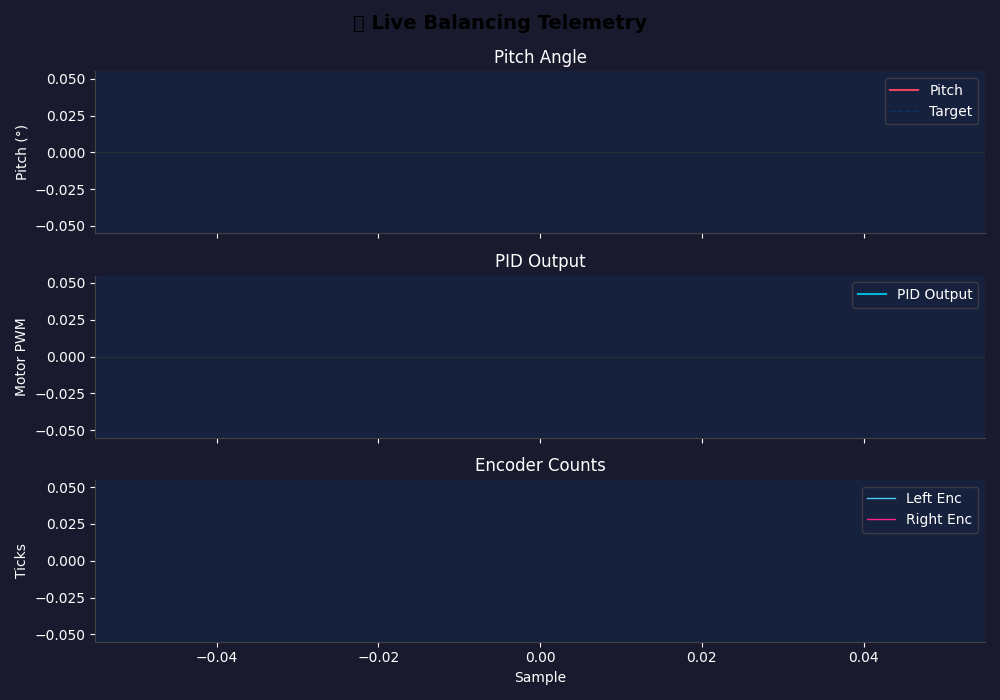

In [12]:
%matplotlib widget

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle('🤖 Live Balancing Telemetry', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#1a1a2e')

for ax in (ax1, ax2, ax3):
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.label.set_color('white')
    ax.xaxis.label.set_color('white')
    ax.title.set_color('white')

line_pitch, = ax1.plot([], [], color='#e94560', linewidth=1.5, label='Pitch')
line_target, = ax1.plot([], [], color='#0f3460', linewidth=1, linestyle='--', label='Target')
ax1.set_ylabel('Pitch (°)')
ax1.set_title('Pitch Angle')
ax1.axhline(y=0, color='#333', linewidth=0.5)
ax1.legend(loc='upper right', facecolor='#16213e', edgecolor='#444', labelcolor='white')

line_pid, = ax2.plot([], [], color='#00b4d8', linewidth=1.5, label='PID Output')
ax2.set_ylabel('Motor PWM')
ax2.set_title('PID Output')
ax2.axhline(y=0, color='#333', linewidth=0.5)
ax2.legend(loc='upper right', facecolor='#16213e', edgecolor='#444', labelcolor='white')

line_encl, = ax3.plot([], [], color='#4cc9f0', linewidth=1, label='Left Enc')
line_encr, = ax3.plot([], [], color='#f72585', linewidth=1, label='Right Enc')
ax3.set_ylabel('Ticks')
ax3.set_xlabel('Sample')
ax3.set_title('Encoder Counts')
ax3.legend(loc='upper right', facecolor='#16213e', edgecolor='#444', labelcolor='white')

fig.tight_layout()

def update_plot(frame):
    n = len(history['pitch'])
    if n < 2:
        return line_pitch, line_pid, line_encl, line_encr
    
    x = list(range(n))
    
    line_pitch.set_data(x, list(history['pitch']))
    line_target.set_data(x, [state['target']] * n)
    ax1.set_xlim(0, max(n, 50))
    pmax = max(abs(min(history['pitch'])), abs(max(history['pitch'])), 5)
    ax1.set_ylim(-pmax * 1.2, pmax * 1.2)
    
    line_pid.set_data(x, list(history['pid_out']))
    ax2.set_xlim(0, max(n, 50))
    pidmax = max(abs(min(history['pid_out'])), abs(max(history['pid_out'])), 10)
    ax2.set_ylim(-pidmax * 1.2, pidmax * 1.2)
    
    line_encl.set_data(x, list(history['enc_l']))
    line_encr.set_data(x, list(history['enc_r']))
    ax3.set_xlim(0, max(n, 50))
    all_enc = list(history['enc_l']) + list(history['enc_r'])
    if all_enc:
        ax3.set_ylim(min(all_enc) - 10, max(all_enc) + 10)
    
    return line_pitch, line_pid, line_encl, line_encr

ani = FuncAnimation(fig, update_plot, interval=100, blit=False, cache_frame_data=False)
plt.show()

---
## 🦿 Step 8: Digital Twin Visualization

A side-view stick-figure of the robot showing:
- Body tilt (pitch angle)
- Wheel positions (from encoders)
- Center of gravity indicator

c:\Users\vilas\AppData\Local\Programs\Python\Python310\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 129471 (\N{MECHANICAL LEG}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


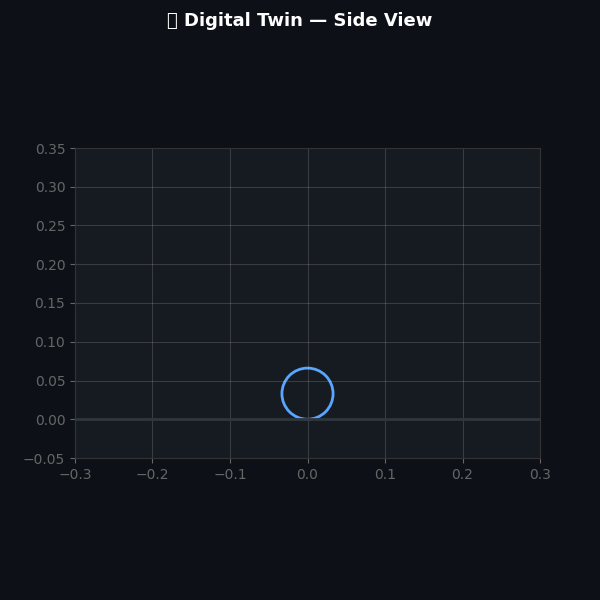

In [13]:
%matplotlib widget

# ============================================================
# DIGITAL TWIN — Side-view stick figure
# ============================================================
WHEEL_R = 0.033       # Wheel radius in meters (33mm)
BODY_H = 0.20         # Body height in meters (200mm from axle to CG)
LEG_L = 0.10          # Leg segment length (upper)

fig_twin, ax_twin = plt.subplots(1, 1, figsize=(6, 6))
fig_twin.suptitle('🦿 Digital Twin — Side View', fontsize=13, fontweight='bold', color='white')
fig_twin.patch.set_facecolor('#0d1117')
ax_twin.set_facecolor('#161b22')
ax_twin.set_xlim(-0.3, 0.3)
ax_twin.set_ylim(-0.05, 0.35)
ax_twin.set_aspect('equal')
ax_twin.grid(True, alpha=0.15, color='white')
ax_twin.tick_params(colors='#666')
for spine in ax_twin.spines.values():
    spine.set_color('#333')

# Ground line
ax_twin.axhline(y=0, color='#30363d', linewidth=2)

# Robot elements (initialized empty)
wheel_circle = plt.Circle((0, WHEEL_R), WHEEL_R, fill=False, color='#58a6ff', linewidth=2)
ax_twin.add_patch(wheel_circle)

body_line, = ax_twin.plot([], [], color='#f0883e', linewidth=4, solid_capstyle='round')
cg_dot, = ax_twin.plot([], [], 'o', color='#e94560', markersize=10, zorder=5)
head_dot, = ax_twin.plot([], [], 's', color='#7ee787', markersize=8, zorder=5)

# Angle arc (visual indicator)
angle_text = ax_twin.text(0.15, 0.30, '', fontsize=12, color='#e94560', fontweight='bold')
status_text = ax_twin.text(-0.28, 0.32, '', fontsize=9, color='#8b949e', family='monospace')

def update_twin(frame):
    pitch_rad = np.radians(state['pitch'])
    
    # Axle position (wheel center)
    axle_x, axle_y = 0, WHEEL_R
    
    # Body top (tilted by pitch)
    top_x = axle_x + BODY_H * np.sin(pitch_rad)
    top_y = axle_y + BODY_H * np.cos(pitch_rad)
    
    # CG at ~60% of body height
    cg_x = axle_x + 0.6 * BODY_H * np.sin(pitch_rad)
    cg_y = axle_y + 0.6 * BODY_H * np.cos(pitch_rad)
    
    body_line.set_data([axle_x, top_x], [axle_y, top_y])
    cg_dot.set_data([cg_x], [cg_y])
    head_dot.set_data([top_x], [top_y])
    
    # Wheel spoke to show rotation
    wheel_circle.center = (axle_x, axle_y)
    
    # Text updates
    angle_text.set_text(f"{state['pitch']:+.1f}°")
    motors_str = '⚡ON' if state['motors_on'] else '🛑OFF'
    status_text.set_text(
        f"Kp={state['Kp']:.1f} Ki={state['Ki']:.1f} Kd={state['Kd']:.1f}\n"
        f"PID={state['pid_out']:+.0f}  Motors: {motors_str}\n"
        f"EncL={state['enc_l']}  EncR={state['enc_r']}"
    )
    
    return body_line, cg_dot, head_dot, angle_text, status_text

ani_twin = FuncAnimation(fig_twin, update_twin, interval=50, blit=False, cache_frame_data=False)
plt.show()

---
## ⚡ Step 9: Quick Commands

Handy cells to send individual commands without the slider UI.

In [14]:
# ============================================================
# QUICK PID SET — Edit values and run
# ============================================================
KP = 20.0
KI = 0.5
KD = 1.0
TARGET = 0.0

send(f'P{KP}')
send(f'I{KI}')
send(f'D{KD}')
send(f'S{TARGET}')

print(f"✅ Sent: Kp={KP}, Ki={KI}, Kd={KD}, Target={TARGET}°")

✅ Sent: Kp=20.0, Ki=0.5, Kd=1.0, Target=0.0°


In [15]:
# ============================================================
# TOGGLE MOTORS ON/OFF
# ============================================================
send('M')
time.sleep(0.3)
print(f"Motors are now: {'⚡ ON' if state['motors_on'] else '🛑 OFF'}")

Motors are now: ⚡ ON


In [ ]:
# ============================================================
# 🚨 EMERGENCY STOP — Run this if anything goes wrong!
# ============================================================
send('P0')
send('I0')
send('D0')
if state['motors_on']:
    send('M')  # Toggle motors off
print("🚨 EMERGENCY STOP — PID zeroed, motors disabled")

---
## 💾 Step 10: Save & Load Session Data

Record a balancing session and save it for later analysis.

In [ ]:
# ============================================================
# SAVE SESSION LOG
# ============================================================
if session_log:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'session_{timestamp}.json'
    
    session_data = {
        'metadata': {
            'timestamp': timestamp,
            'samples': len(session_log),
            'pid': {'Kp': state['Kp'], 'Ki': state['Ki'], 'Kd': state['Kd']},
            'target': state['target'],
            'offset': state['offset'],
        },
        'data': session_log
    }
    
    with open(filename, 'w') as f:
        json.dump(session_data, f, indent=2)
    
    print(f"✅ Saved {len(session_log)} samples to {filename}")
    print(f"   PID: Kp={state['Kp']}, Ki={state['Ki']}, Kd={state['Kd']}")
else:
    print("⚠️ No data to save — run a session first!")

In [ ]:
# ============================================================
# CLEAR SESSION LOG (start fresh recording)
# ============================================================
session_log.clear()
print("🗑️ Session log cleared — ready for new recording")

---
## 📊 Step 11: Post-Session Analysis

Load a saved session and analyze the balancing performance.

In [ ]:
# ============================================================
# LOAD & ANALYZE A SESSION
# ============================================================
# List saved sessions
sessions = sorted([f for f in os.listdir('.') if f.startswith('session_') and f.endswith('.json')])
if sessions:
    print("Saved sessions:")
    for i, s in enumerate(sessions):
        print(f"  [{i}] {s}")
else:
    print("No saved sessions found.")

In [ ]:
# ============================================================
# PLOT A SESSION — change index to pick which session
# ============================================================
SESSION_INDEX = -1  # -1 = most recent

if sessions:
    with open(sessions[SESSION_INDEX], 'r') as f:
        data = json.load(f)
    
    meta = data['metadata']
    samples = data['data']
    
    t0 = samples[0]['t']
    times = [(s['t'] - t0) for s in samples]
    pitches = [s['pitch'] for s in samples]
    pid_outs = [s['pid_out'] for s in samples]
    
    fig_a, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig_a.suptitle(f"Session: {sessions[SESSION_INDEX]}\n"
                   f"Kp={meta['pid']['Kp']}  Ki={meta['pid']['Ki']}  Kd={meta['pid']['Kd']}",
                   fontsize=12)
    
    a1.plot(times, pitches, color='#e94560', linewidth=0.8)
    a1.axhline(y=meta['target'], color='gray', linestyle='--', label=f"Target={meta['target']}°")
    a1.set_ylabel('Pitch (°)')
    a1.legend()
    a1.grid(alpha=0.3)
    
    a2.plot(times, pid_outs, color='#00b4d8', linewidth=0.8)
    a2.set_ylabel('PID Output')
    a2.set_xlabel('Time (s)')
    a2.grid(alpha=0.3)
    
    fig_a.tight_layout()
    plt.show()
    
    # Statistics
    pitch_arr = np.array(pitches)
    print(f"\n📊 Statistics ({len(samples)} samples, {times[-1]:.1f}s):")
    print(f"   Pitch — Mean: {np.mean(pitch_arr):.2f}°  StdDev: {np.std(pitch_arr):.2f}°  "
          f"Max: {np.max(np.abs(pitch_arr)):.2f}°")
    print(f"   Time in ±5°: {np.sum(np.abs(pitch_arr) < 5) / len(pitch_arr) * 100:.1f}%")
    print(f"   Time in ±2°: {np.sum(np.abs(pitch_arr) < 2) / len(pitch_arr) * 100:.1f}%")
else:
    print("No sessions to analyze.")

---
## 🔌 Step 12: Disconnect

Always disable motors and close the serial port when done.

In [ ]:
# ============================================================
# SAFE SHUTDOWN
# ============================================================
# 1. Zero all PID gains
send('P0')
send('I0')
send('D0')

# 2. Disable motors if on
if state['motors_on']:
    send('M')

# 3. Stop reader thread
reader_running = False
time.sleep(0.3)

# 4. Close serial
if ser and ser.is_open:
    ser.close()
    print("✅ Serial port closed")

print("✅ Safe shutdown complete — motors OFF, PID zeroed, serial closed")